In [1]:
import pandas as pd

In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\rkhadka1\OneDrive - Lamar University\Research\Roshanbeam3\Cleaned data\4magnets_04g.csv')
df.head()


,time,tip_acc,tip_vel,tip_disp,mid_acc,mid_vel,mid_disp,base_acc,base_vel,base_disp
0,0.000000,-209.463434,-0.831139,0.006474,88.306736,0.414253,-0.002738,3.847060,-0.003837,-0.000119
1,0.000049,-208.147781,-0.841334,0.006433,87.395969,0.418543,-0.002717,3.854098,-0.003649,-0.000119
2,0.000098,-206.816144,-0.851465,0.006392,86.479351,0.422788,-0.002696,3.860842,-0.003460,-0.000119
3,0.000146,-205.468622,-0.861531,0.006349,85.557080,0.426988,-0.002675,3.867292,-0.003272,-0.000119
4,0.000195,-204.105312,-0.871530,0.006307,84.629354,0.431143,-0.002654,3.873447,-0.003083,-0.000119


In [3]:
df_relative = pd.DataFrame()
df_relative['time'] = df['time']

df_relative['tip_rel_acc'] = df['tip_acc'] - df['base_acc']
df_relative['tip_rel_vel'] = df['tip_vel'] - df['base_vel']
df_relative['tip_rel_disp'] = df['tip_disp'] - df['base_disp']

df_relative['mid_rel_acc'] = df['mid_acc'] - df['base_acc']
df_relative['mid_rel_vel'] = df['mid_vel'] - df['base_vel']
df_relative['mid_rel_disp'] = df['mid_disp'] - df['base_disp']

display(df_relative.head())

,time,tip_rel_acc,tip_rel_vel,tip_rel_disp,mid_rel_acc,mid_rel_vel,mid_rel_disp
0,0.000000,-213.310493,-0.827302,0.006593,84.459677,0.418090,-0.002619
1,0.000049,-212.001878,-0.837686,0.006552,83.541871,0.422191,-0.002598
2,0.000098,-210.676987,-0.848005,0.006511,82.618508,0.426248,-0.002577
3,0.000146,-209.335914,-0.858259,0.006469,81.689788,0.430260,-0.002556
4,0.000195,-207.978759,-0.868448,0.006426,80.755908,0.434226,-0.002534


Eigen vector, value and damping

In [4]:
import numpy as np

#ANSYS simulation modeshape:
P = np.array([[5.7189, 6.8386],[1.1655,-4.7703]])

#Inverse of Modal Matrix
try:
    P_inv = np.linalg.inv(P)
    print("Original Matrix:\n", P)
    print("\nInverse Matrix:\n", P_inv)

    # 3. (Optional) Verify the inversion: A * A_inv should yield the identity matrix
    identity_check = np.matmul(P, P_inv)
    print("\nIdentity Check (A * A_inv):\n", identity_check)

except np.linalg.LinAlgError as e:
    print(f"Error: {e}")
    print("The matrix is likely singular and cannot be inverted.")

#Eigen Value
Wn = np.array([[180.39025, 0],[0, 1398.259]])
Wn2 = np.square(Wn)
print(Wn2)


#2zwn term
zwn = np.array([[2.1646,0],[0,16.77911]])

Original Matrix:
 [[ 5.7189  6.8386]
 [ 1.1655 -4.7703]]

Inverse Matrix:
 [[ 0.13532283  0.19399592]
 [ 0.03306265 -0.16223251]]

Identity Check (A * A_inv):
 [[1.00000000e+00 1.06318194e-16]
 [1.30416203e-17 1.00000000e+00]]
[[  32540.64229506       0.        ]
 [      0.         1955128.231081  ]]


Modal acceleration

In [5]:
u_ddot_1 = df_relative['tip_rel_acc']
u_ddot_2 = df_relative['mid_rel_acc']
u_ddot_combined = np.array([u_ddot_1, u_ddot_2])
print(u_ddot_combined)
print('The modal acceleration is:')
q_ddot_combined = np.matmul(P_inv, u_ddot_combined)
print(q_ddot_combined)
Modal_acceleration_flat = q_ddot_combined.ravel()
Modal_acceleration_df = pd.DataFrame(Modal_acceleration_flat, columns=['Modal_acceleration'])
print('the shape of modal acceleration is:',Modal_acceleration_df.shape)
display(Modal_acceleration_df.head())

[[-213.31049319 -212.00187826 -210.67698673 ...  263.85316437
   263.62368893  263.37311877]
 [  84.45967694   83.54187116   82.61850831 ... -106.24383034
  -106.08498265 -105.91621169]]
The modal acceleration is:
[[-12.48094782 -12.48191292 -12.48175347 ...  15.09448847  15.094251
   15.09308402]
 [-20.75471598 -20.56255176 -20.36894786 ...  25.95988861  25.92653129
   25.89086664]]
the shape of modal acceleration is: (81922, 1)


,Modal_acceleration
0,-12.480948
1,-12.481913
2,-12.481753
3,-12.480444
4,-12.477959


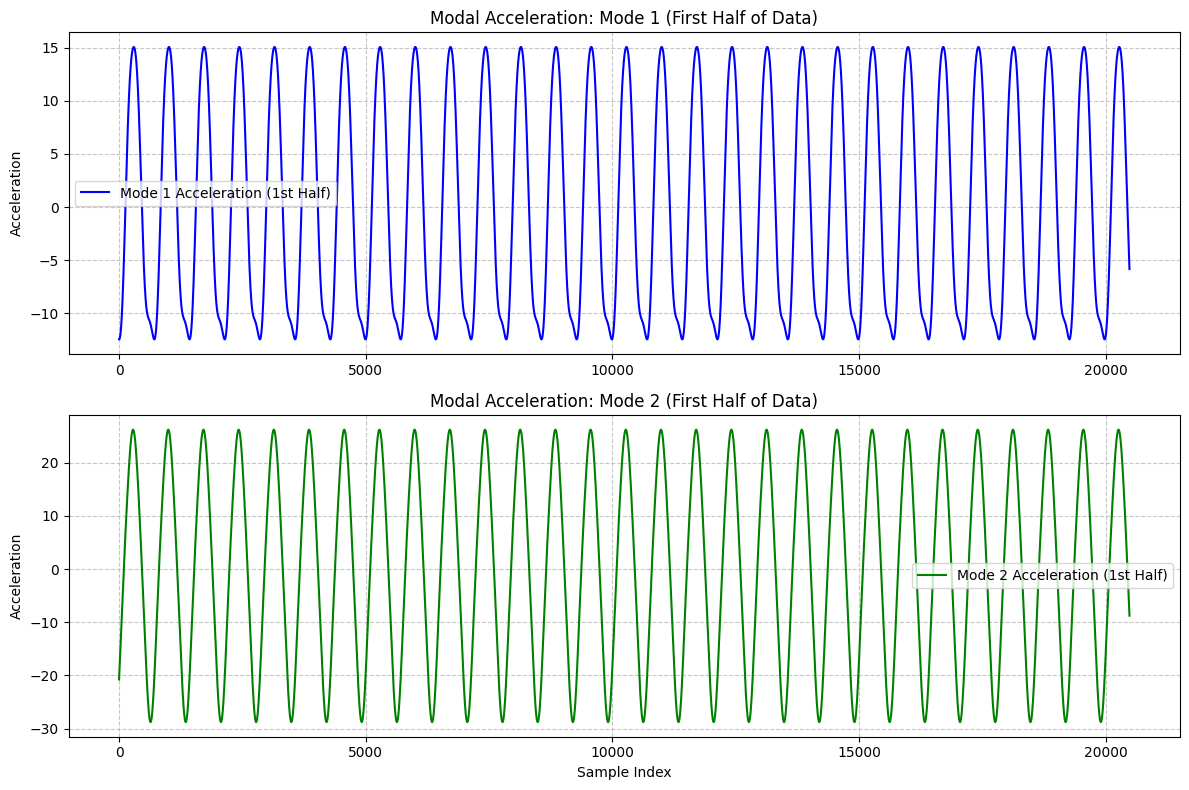

In [6]:
import matplotlib.pyplot as plt


# Calculate split points for the modes and their halves
total_samples = len(Modal_acceleration_df)
half_point = total_samples // 2
quarter_point = half_point // 2

# Mode 1: First half of the first half
mode1_acc = Modal_acceleration_df.iloc[:quarter_point]

# Mode 2: First half of the next half
mode2_acc = Modal_acceleration_df.iloc[half_point : half_point + quarter_point]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Mode 1
ax1.plot(mode1_acc.values, label='Mode 1 Acceleration (1st Half)', color='blue')
ax1.set_title('Modal Acceleration: Mode 1 (First Half of Data)')
ax1.set_ylabel('Acceleration')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot Mode 2
ax2.plot(mode2_acc.values, label='Mode 2 Acceleration (1st Half)', color='green')
ax2.set_title('Modal Acceleration: Mode 2 (First Half of Data)')
ax2.set_ylabel('Acceleration')
ax2.set_xlabel('Sample Index')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

Modal velocity

In [7]:
u_dot_1 = df_relative['tip_rel_vel']
u_dot_2 = df_relative['mid_rel_vel']
u_dot_combined = np.array([u_dot_1, u_dot_2])

print('The relative velocity combined array is:')
print(u_dot_combined)

q_dot_combined = np.matmul(P_inv, u_dot_combined)
print('\nThe modal velocity is:')
print(q_dot_combined)

Modal_velocity_flat = q_dot_combined.ravel()
Modal_velocity_df = pd.DataFrame(Modal_velocity_flat, columns=['Modal_velocity'])
print('\nThe shape of modal velocity is:', Modal_velocity_df.shape)
display(Modal_velocity_df.head())

zwn_q_dot_combined = np.matmul(zwn, q_dot_combined)
print('Shape of zwn_q_dot_combined:', zwn_q_dot_combined.shape)

zwn_modal_velocity_flat = zwn_q_dot_combined.ravel()
zwn_modal_velocity_df = pd.DataFrame(zwn_modal_velocity_flat, columns=['zwn_modal_velocity'])

print('\nShape of zwn_modal_velocity_df:', zwn_modal_velocity_df.shape)
display(zwn_modal_velocity_df.head())

The relative velocity combined array is:
[[-0.82730215 -0.83768582 -0.84800519 ...  0.14603709  0.15891503
   0.17178125]
 [ 0.41808986  0.42219149  0.42624816 ... -0.09930881 -0.10449266
  -0.10966851]]

The modal velocity is:
[[-0.03084514 -0.03145459 -0.03206406 ...  0.00049665  0.00123368
   0.00197068]
 [-0.09518057 -0.0961893  -0.09718861 ...  0.02093949  0.02220626
   0.02347134]]

The shape of modal velocity is: (81922, 1)


,Modal_velocity
0,-0.030845
1,-0.031455
2,-0.032064
3,-0.032673
4,-0.033283


Shape of zwn_q_dot_combined: (2, 40961)

Shape of zwn_modal_velocity_df: (81922, 1)


,zwn_modal_velocity
0,-0.066767
1,-0.068087
2,-0.069406
3,-0.070725
4,-0.072044


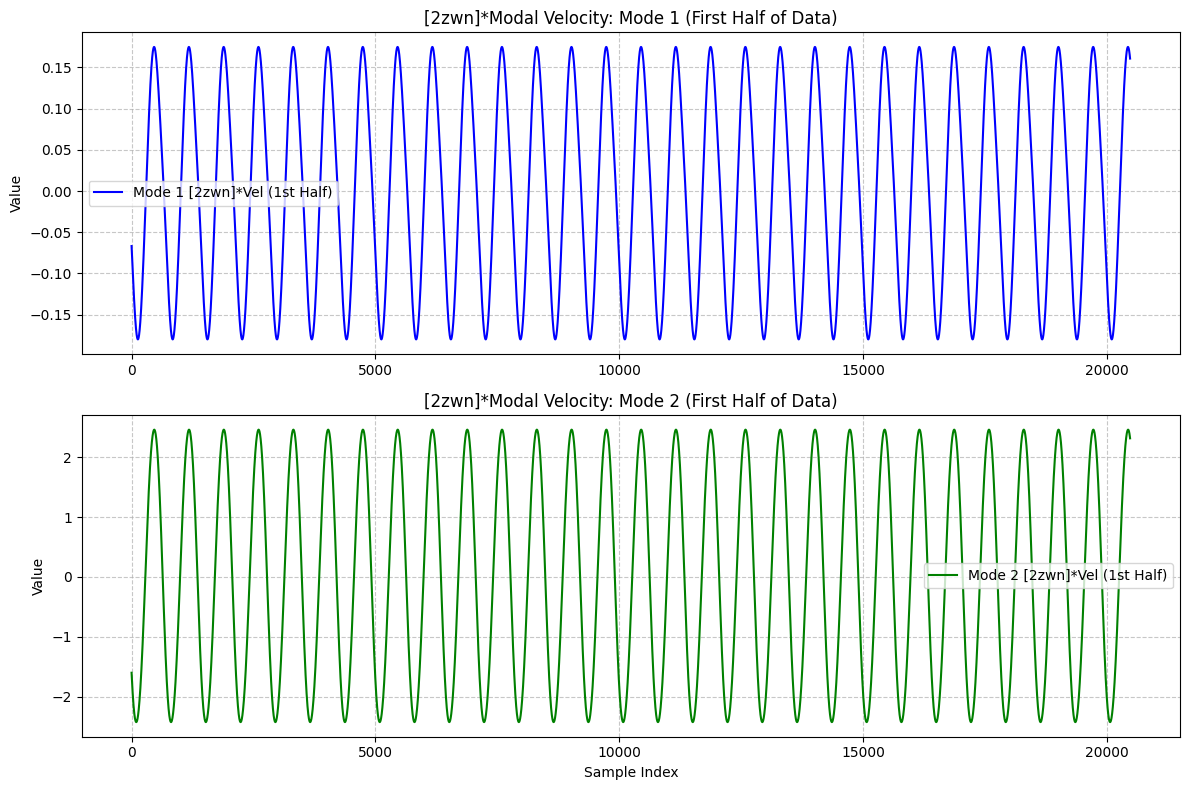

In [8]:
# Calculate split points for the modes and their halves
total_samples_vel = len(zwn_modal_velocity_df)
half_point_vel = total_samples_vel // 2
quarter_point_vel = half_point_vel // 2

# Mode 1: First half of the first half
mode1_zwn_vel = zwn_modal_velocity_df.iloc[:quarter_point_vel]

# Mode 2: First half of the next half
mode2_zwn_vel = zwn_modal_velocity_df.iloc[half_point_vel : half_point_vel + quarter_point_vel]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Mode 1
ax1.plot(mode1_zwn_vel.values, label='Mode 1 [2zwn]*Vel (1st Half)', color='blue')
ax1.set_title('[2zwn]*Modal Velocity: Mode 1 (First Half of Data)')
ax1.set_ylabel('Value')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot Mode 2
ax2.plot(mode2_zwn_vel.values, label='Mode 2 [2zwn]*Vel (1st Half)', color='green')
ax2.set_title('[2zwn]*Modal Velocity: Mode 2 (First Half of Data)')
ax2.set_ylabel('Value')
ax2.set_xlabel('Sample Index')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

Modal displacement

In [9]:
u_1 = df_relative['tip_rel_disp']
u_2 = df_relative['mid_rel_disp']
u_combined = np.array([u_1, u_2])

print('The relative displacement combined array is:')
print(u_combined)

q_combined = np.matmul(P_inv, u_combined)
print('\nThe modal displacement is:')
print(q_combined)

Modal_displacement_flat = q_combined.ravel()
Modal_displacement_df = pd.DataFrame(Modal_displacement_flat, columns=['Modal_displacement'])
print('\nThe shape of modal displacement is:', Modal_displacement_df.shape)
display(Modal_displacement_df.head())

wn2_q_combined = np.matmul(Wn2, q_combined)
print('Shape of wn2_q_combined:', wn2_q_combined.shape)

wn2_modal_displacement_flat = wn2_q_combined.ravel()
wn2_modal_displacement_df = pd.DataFrame(wn2_modal_displacement_flat, columns=['wn2_modal_displacement'])

print('\nShape of wn2_modal_displacement_df:', wn2_modal_displacement_df.shape)
display(wn2_modal_displacement_df.head())

The relative displacement combined array is:
[[ 0.00659306  0.00655205  0.00651053 ... -0.00803391 -0.00802683
  -0.00801912]
 [-0.00261914 -0.00259822 -0.00257711 ...  0.00329282  0.0032879
   0.00328273]]

The modal displacement is:
[[ 0.00038409  0.0003826   0.00038107 ... -0.00044838 -0.00044837
  -0.00044833]
 [ 0.00064289  0.00063814  0.00063335 ... -0.00079983 -0.00079879
  -0.0007977 ]]

The shape of modal displacement is: (81922, 1)


,Modal_displacement
0,0.000384
1,0.000383
2,0.000381
3,0.000380
4,0.000378


Shape of wn2_q_combined: (2, 40961)

Shape of wn2_modal_displacement_df: (81922, 1)


,wn2_modal_displacement
0,12.498515
1,12.449961
2,12.400424
3,12.349902
4,12.298395


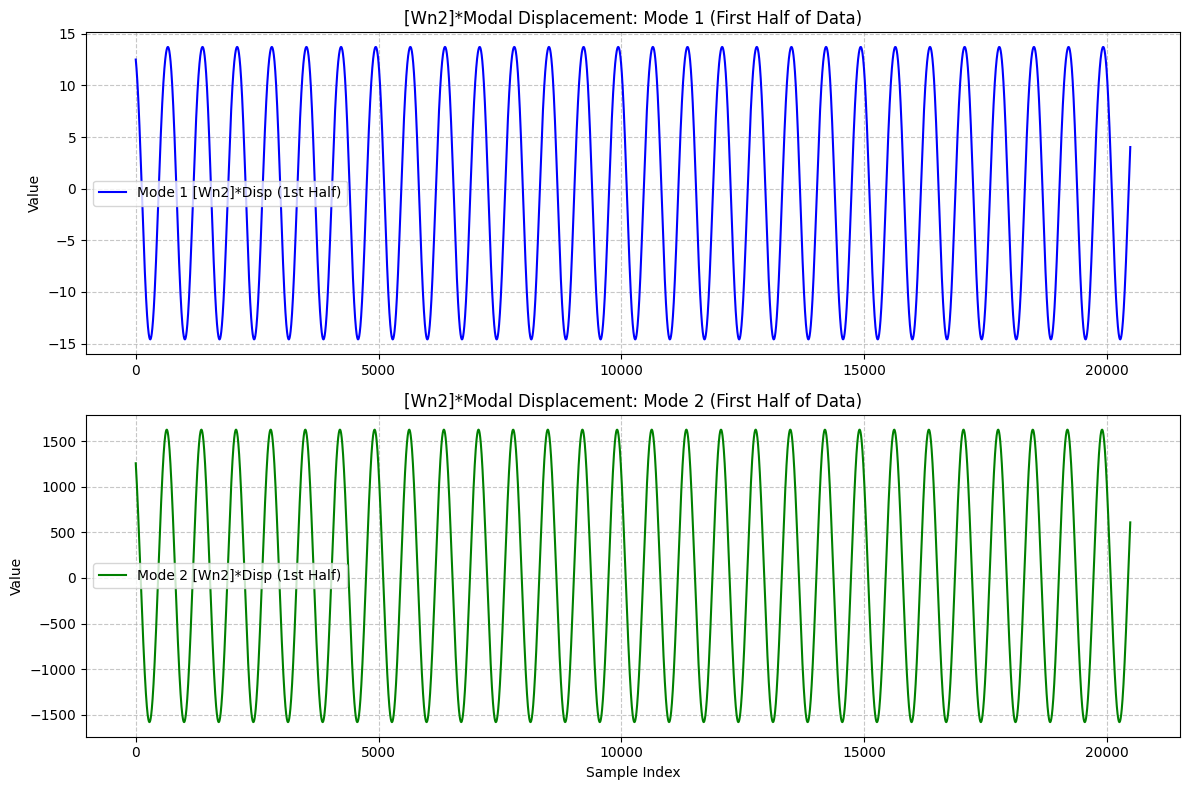

In [10]:
# Calculate split points for the modes and their halves
total_samples_disp = len(wn2_modal_displacement_df)
half_point_disp = total_samples_disp // 2
quarter_point_disp = half_point_disp // 2

# Mode 1: First half of the first half
mode1_wn2_disp = wn2_modal_displacement_df.iloc[:quarter_point_disp]

# Mode 2: First half of the next half
mode2_wn2_disp = wn2_modal_displacement_df.iloc[half_point_disp : half_point_disp + quarter_point_disp]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Mode 1
ax1.plot(mode1_wn2_disp.values, label='Mode 1 [Wn2]*Disp (1st Half)', color='blue')
ax1.set_title('[Wn2]*Modal Displacement: Mode 1 (First Half of Data)')
ax1.set_ylabel('Value')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot Mode 2
ax2.plot(mode2_wn2_disp.values, label='Mode 2 [Wn2]*Disp (1st Half)', color='green')
ax2.set_title('[Wn2]*Modal Displacement: Mode 2 (First Half of Data)')
ax2.set_ylabel('Value')
ax2.set_xlabel('Sample Index')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

Modal base excitation

In [11]:
#Transformation Vector
L = np.array([[1],[1]])

base_excitation_02g = df['base_acc']
Base_excitation_flat_02g = base_excitation_02g.values.ravel()
Base_excitation_df_02g = pd.DataFrame(Base_excitation_flat_02g, columns=['Base_Excitation'])


Modal_transformation = np.matmul(P_inv, L)
print(Modal_transformation)

# Calculate modal base excitation
modal_base_excitation_02g = Modal_transformation * base_excitation_02g.to_numpy()
modal_base_excitation_02g_flat = modal_base_excitation_02g.ravel()
modal_base_excitation_02g_df = pd.DataFrame(modal_base_excitation_02g_flat, columns=['Modal_Base_Excitation'])
print('Shape of modal_base_excitation_02g_df:', modal_base_excitation_02g_df.shape)
display(modal_base_excitation_02g_df.head())

[[ 0.32931875]
 [-0.12916986]]
Shape of modal_base_excitation_02g_df: (81922, 1)


,Modal_Base_Excitation
0,1.266909
1,1.269227
2,1.271448
3,1.273572
4,1.275599


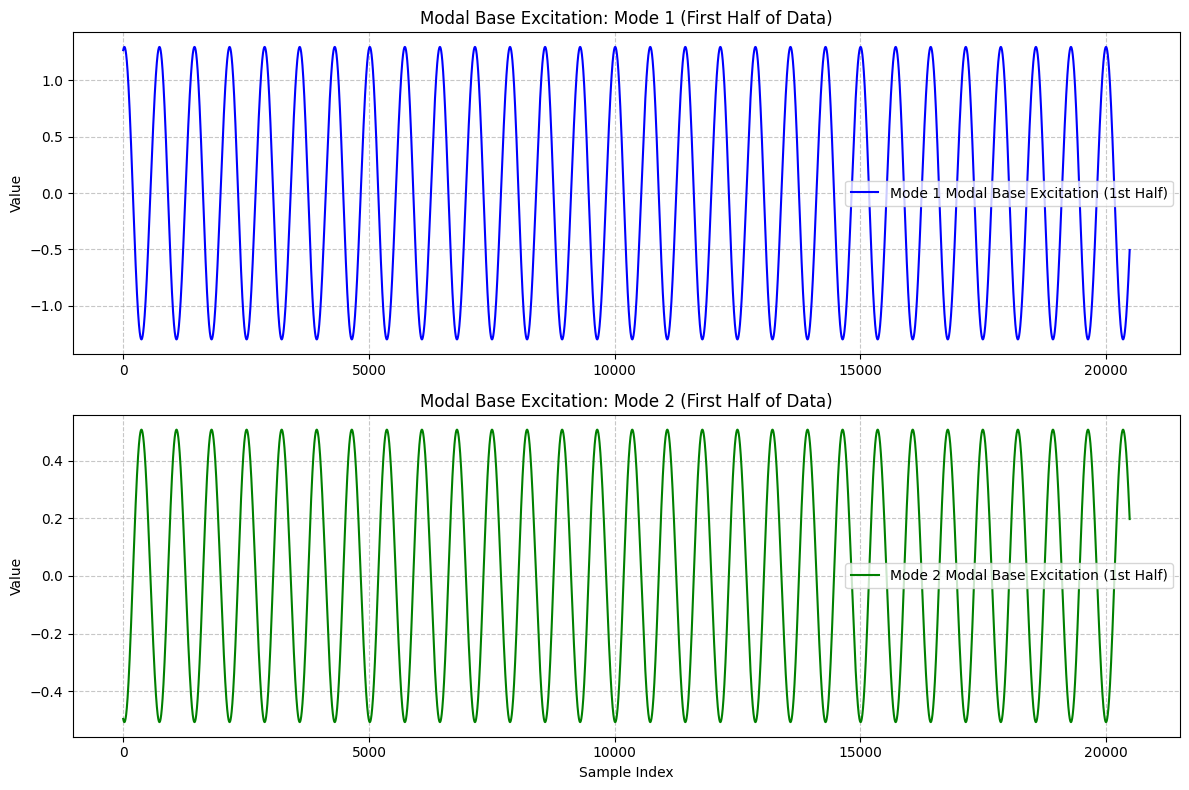

In [12]:
# Calculate split points for the modes and their halves
total_samples_base = len(modal_base_excitation_02g_df)
half_point_base = total_samples_base // 2
quarter_point_base = half_point_base // 2

# Mode 1: First half of the first half
mode1_base_exc = modal_base_excitation_02g_df.iloc[:quarter_point_base]

# Mode 2: First half of the next half
mode2_base_exc = modal_base_excitation_02g_df.iloc[half_point_base : half_point_base + quarter_point_base]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Mode 1
ax1.plot(mode1_base_exc.values, label='Mode 1 Modal Base Excitation (1st Half)', color='blue')
ax1.set_title('Modal Base Excitation: Mode 1 (First Half of Data)')
ax1.set_ylabel('Value')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot Mode 2
ax2.plot(mode2_base_exc.values, label='Mode 2 Modal Base Excitation (1st Half)', color='green')
ax2.set_title('Modal Base Excitation: Mode 2 (First Half of Data)')
ax2.set_ylabel('Value')
ax2.set_xlabel('Sample Index')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

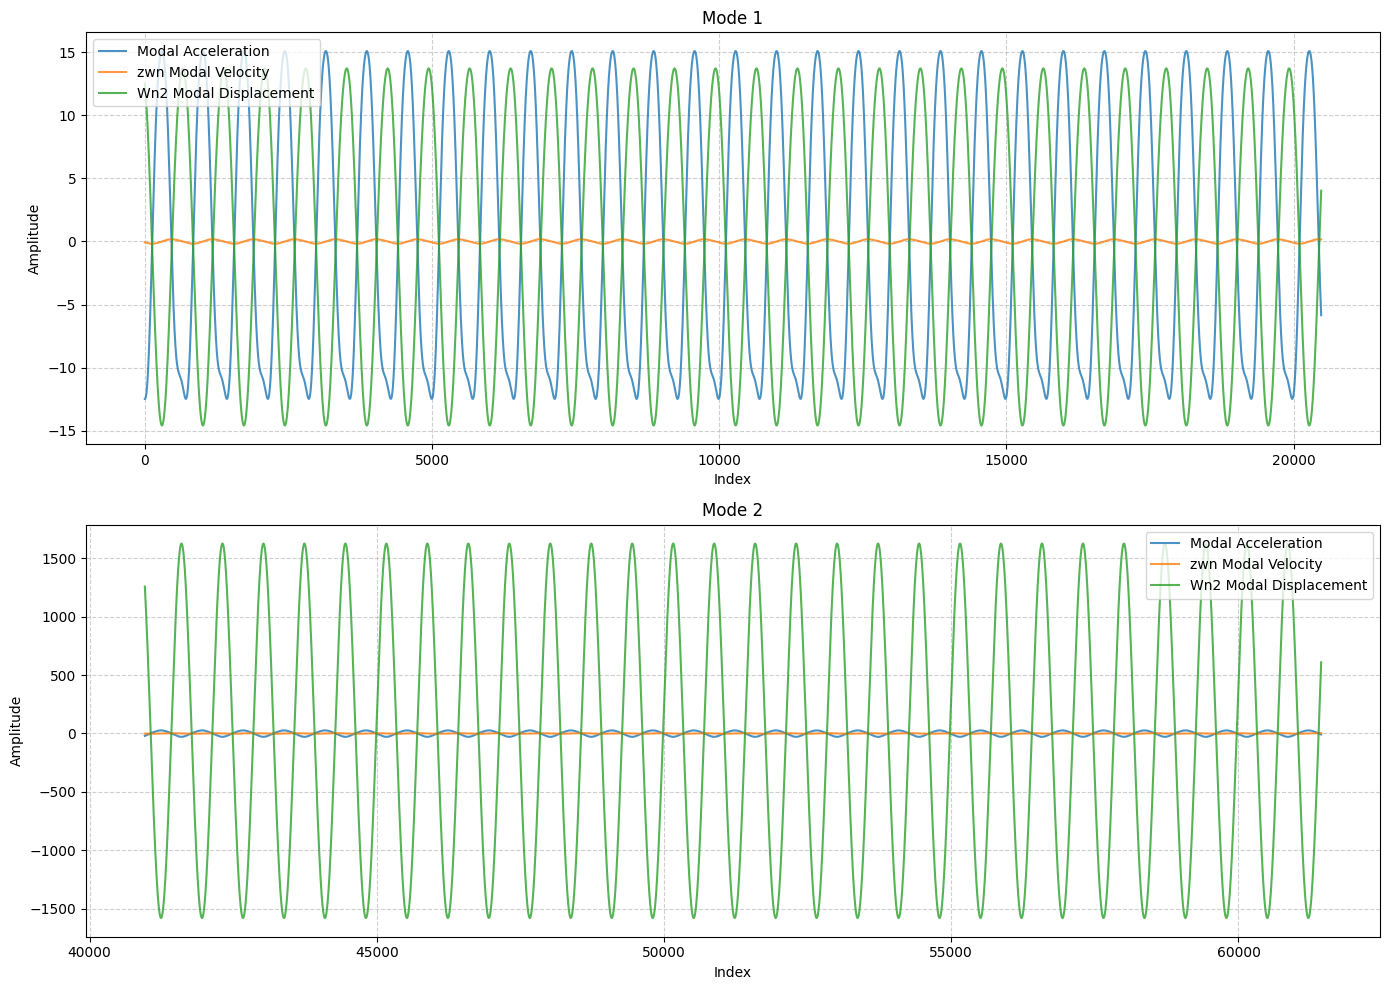

In [13]:
import matplotlib.pyplot as plt

# Calculate length and key indices
N = len(Modal_acceleration_df)
q1_end = N // 4
mid = N // 2
q3_end = mid + (N // 4)

# Prepare the data segments
# First 1/4th
acc_q1 = Modal_acceleration_df.iloc[:q1_end]
vel_q1 = zwn_modal_velocity_df.iloc[:q1_end]
disp_q1 = wn2_modal_displacement_df.iloc[:q1_end]

# 1/4th to the right of mid (3rd quarter)
acc_q3 = Modal_acceleration_df.iloc[mid:q3_end]
vel_q3 = zwn_modal_velocity_df.iloc[mid:q3_end]
disp_q3 = wn2_modal_displacement_df.iloc[mid:q3_end]

# Create the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: First 1/4th
ax1.plot(acc_q1.index, acc_q1['Modal_acceleration'], label='Modal Acceleration', alpha=0.8)
ax1.plot(vel_q1.index, vel_q1['zwn_modal_velocity'], label='zwn Modal Velocity', alpha=0.8)
ax1.plot(disp_q1.index, disp_q1['wn2_modal_displacement'], label='Wn2 Modal Displacement', alpha=0.8)
ax1.set_title('Mode 1')
ax1.set_xlabel('Index')
ax1.set_ylabel('Amplitude')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: 1/4th to the right of mid (3rd Quarter)
ax2.plot(acc_q3.index, acc_q3['Modal_acceleration'], label='Modal Acceleration', alpha=0.8)
ax2.plot(vel_q3.index, vel_q3['zwn_modal_velocity'], label='zwn Modal Velocity', alpha=0.8)
ax2.plot(disp_q3.index, disp_q3['wn2_modal_displacement'], label='Wn2 Modal Displacement', alpha=0.8)
ax2.set_title('Mode 2')
ax2.set_xlabel('Index')
ax2.set_ylabel('Amplitude')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [14]:
Non_linear_force_02g  = -modal_base_excitation_02g_df['Modal_Base_Excitation']- Modal_acceleration_df['Modal_acceleration']- zwn_modal_velocity_df['zwn_modal_velocity']- wn2_modal_displacement_df['wn2_modal_displacement']

Non_linear_force_02g_flat = Non_linear_force_02g.values.ravel()
Non_linear_force_02g_df = pd.DataFrame(Non_linear_force_02g_flat, columns=['Non_Linear_Force'])
print('Shape of Non_linear_force_02g_df:', Non_linear_force_02g_df.shape)
display(Non_linear_force_02g_df.head())

Shape of Non_linear_force_02g_df: (81922, 1)


,Non_Linear_Force
0,-1.217709
1,-1.169188
2,-1.120712
3,-1.072305
4,-1.023991


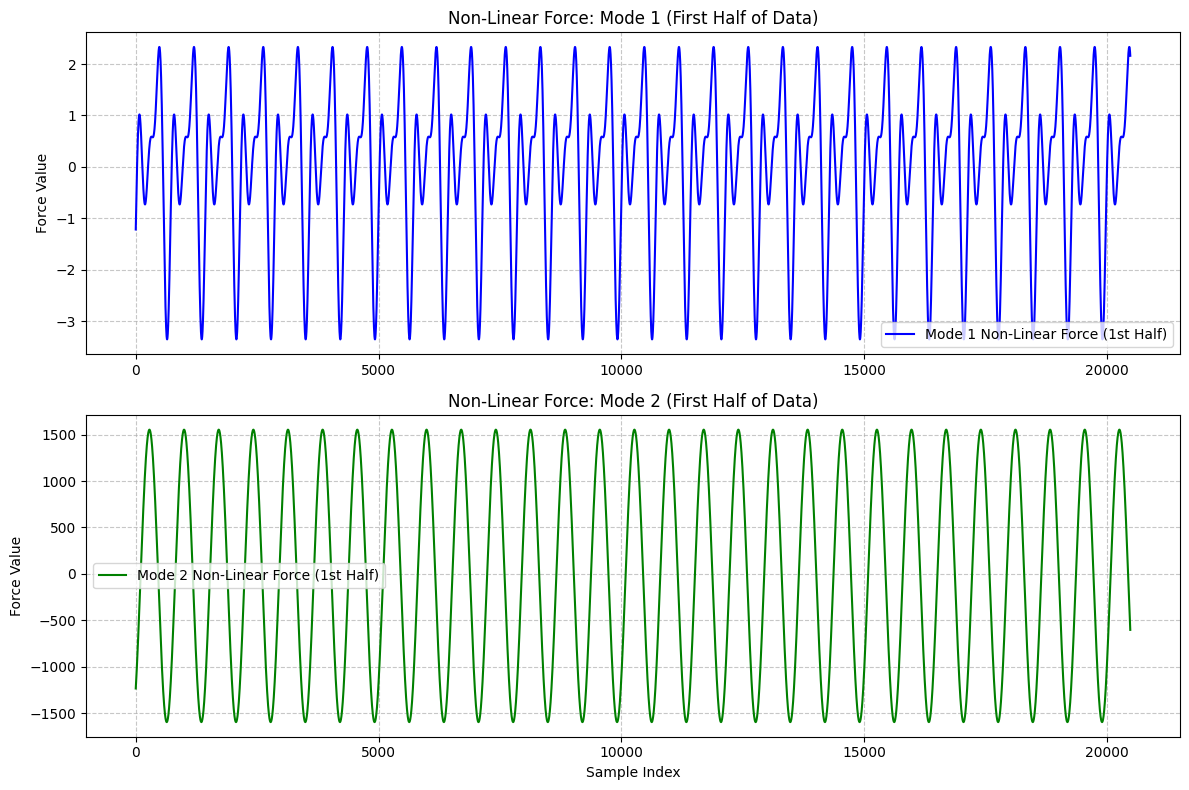

In [15]:
# Calculate split points for the modes and their halves
total_samples_force = len(Non_linear_force_02g_df)
half_point_force = total_samples_force // 2
quarter_point_force = half_point_force // 2

# Mode 1: First half of the first half
mode1_force = Non_linear_force_02g_df.iloc[:quarter_point_force]

# Mode 2: First half of the next half
mode2_force = Non_linear_force_02g_df.iloc[half_point_force : half_point_force + quarter_point_force]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Mode 1
ax1.plot(mode1_force.values, label='Mode 1 Non-Linear Force (1st Half)', color='blue')
ax1.set_title('Non-Linear Force: Mode 1 (First Half of Data)')
ax1.set_ylabel('Force Value')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot Mode 2
ax2.plot(mode2_force.values, label='Mode 2 Non-Linear Force (1st Half)', color='green')
ax2.set_title('Non-Linear Force: Mode 2 (First Half of Data)')
ax2.set_ylabel('Force Value')
ax2.set_xlabel('Sample Index')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

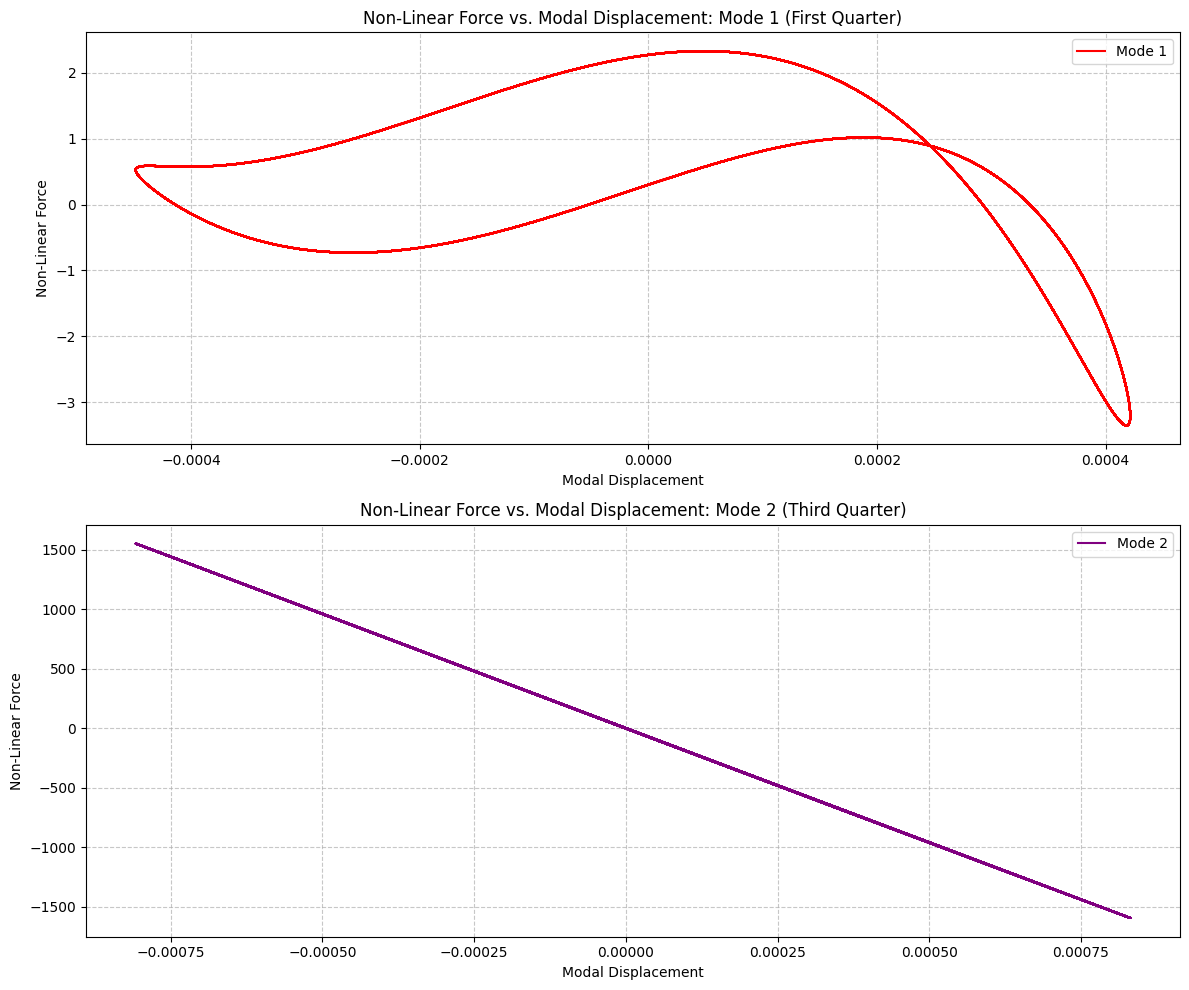

In [16]:
import matplotlib.pyplot as plt

# Reusing the previously calculated split points for consistency
# mode1_wn2_disp_plot, mode1_force_plot, mode2_wn2_disp_plot, mode2_force_plot
import matplotlib.pyplot as plt

# Calculate split points for the modes. Reusing existing variables for consistency.
# total_samples_force, half_point_force, quarter_point_force were calculated earlier and are suitable.

# Mode 1: First half of the first half (first quarter)
mode1_wn2_disp_plot = Modal_displacement_df.iloc[:quarter_point_force]
mode1_force_plot = Non_linear_force_02g_df.iloc[:quarter_point_force]

# Mode 2: First half of the next half (third quarter)
mode2_wn2_disp_plot = Modal_displacement_df.iloc[half_point_force : half_point_force + quarter_point_force]
mode2_force_plot = Non_linear_force_02g_df.iloc[half_point_force : half_point_force + quarter_point_force]
# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Plot Mode 1: Non-Linear Force vs. Modal Displacement
ax1.plot(mode1_wn2_disp_plot.values, mode1_force_plot.values, label='Mode 1', color='red')
ax1.set_title('Non-Linear Force vs. Modal Displacement: Mode 1 (First Quarter)')
ax1.set_xlabel('Modal Displacement')
ax1.set_ylabel('Non-Linear Force')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot Mode 2: Non-Linear Force vs. Modal Displacement
ax2.plot(mode2_wn2_disp_plot.values, mode2_force_plot.values, label='Mode 2', color='purple')
ax2.set_title('Non-Linear Force vs. Modal Displacement: Mode 2 (Third Quarter)')
ax2.set_xlabel('Modal Displacement')
ax2.set_ylabel('Non-Linear Force')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

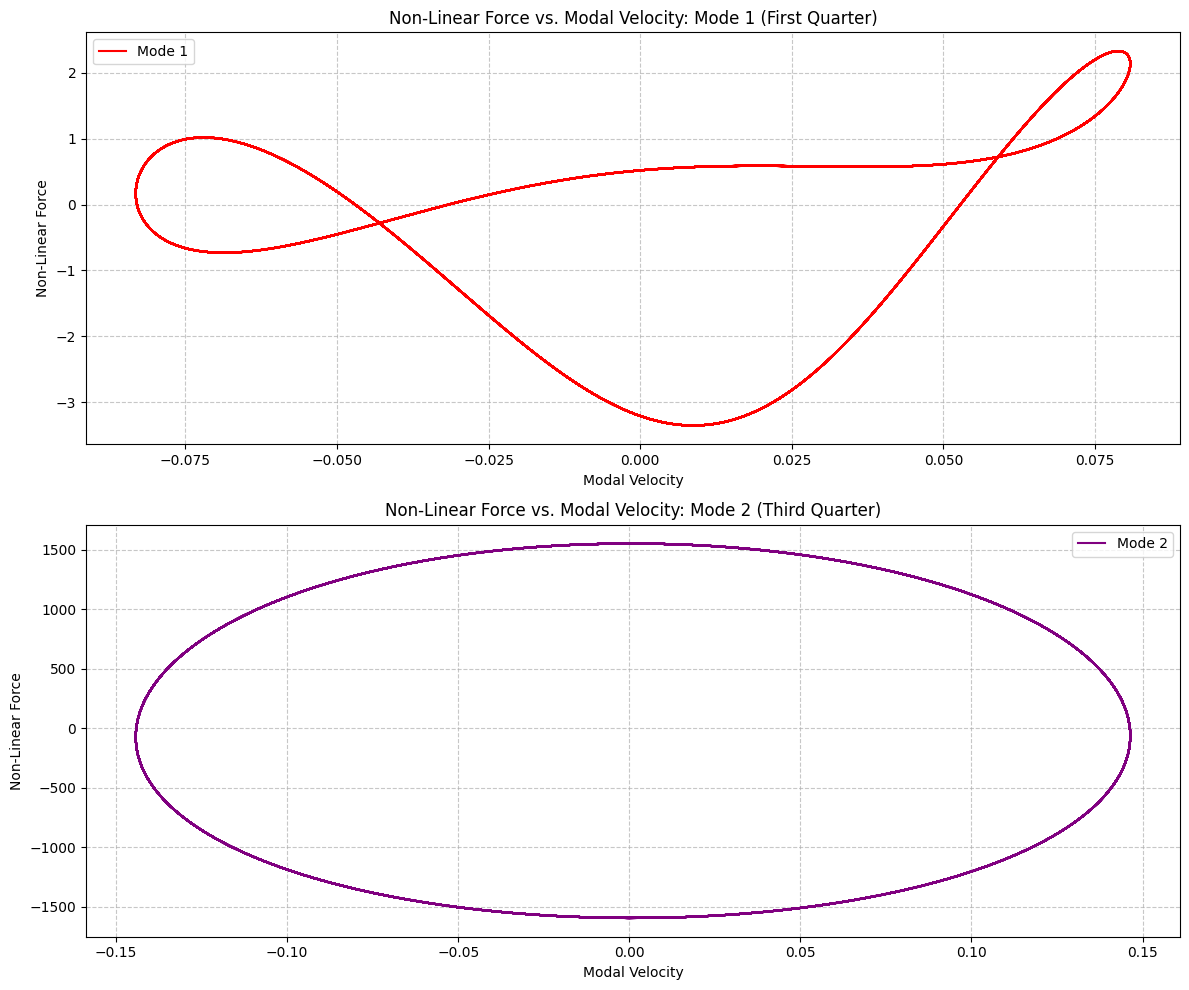

In [17]:
import matplotlib.pyplot as plt

# Reusing the previously calculated split points for consistency
# mode1_wn2_disp_plot, mode1_force_plot, mode2_wn2_disp_plot, mode2_force_plot
import matplotlib.pyplot as plt

# Calculate split points for the modes. Reusing existing variables for consistency.
# total_samples_force, half_point_force, quarter_point_force were calculated earlier and are suitable.

# Mode 1: First half of the first half (first quarter)
mode1_wn2_disp_plot = Modal_velocity_df.iloc[:quarter_point_force]
mode1_force_plot = Non_linear_force_02g_df.iloc[:quarter_point_force]

# Mode 2: First half of the next half (third quarter)
mode2_wn2_disp_plot = Modal_velocity_df.iloc[half_point_force : half_point_force + quarter_point_force]
mode2_force_plot = Non_linear_force_02g_df.iloc[half_point_force : half_point_force + quarter_point_force]
# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# Plot Mode 1: Non-Linear Force vs. Modal Velocity
ax1.plot(mode1_wn2_disp_plot.values, mode1_force_plot.values, label='Mode 1', color='red')
ax1.set_title('Non-Linear Force vs. Modal Velocity: Mode 1 (First Quarter)')
ax1.set_xlabel('Modal Velocity')
ax1.set_ylabel('Non-Linear Force')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot Mode 2: Non-Linear Force vs. Modal Displacement
ax2.plot(mode2_wn2_disp_plot.values, mode2_force_plot.values, label='Mode 2', color='purple')
ax2.set_title('Non-Linear Force vs. Modal Velocity: Mode 2 (Third Quarter)')
ax2.set_xlabel('Modal Velocity')
ax2.set_ylabel('Non-Linear Force')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

In [18]:
# Re-calculate mode-specific non-linear forces using the un-ravelled modal components
# (modal_base_excitation_02g, q_ddot_combined, zwn_q_dot_combined, wn2_q_combined)
Non_linear_force_mode1 = -modal_base_excitation_02g[0, :] - q_ddot_combined[0, :] - zwn_q_dot_combined[0, :] - wn2_q_combined[0, :]
Non_linear_force_mode2 = -modal_base_excitation_02g[1, :] - q_ddot_combined[1, :] - zwn_q_dot_combined[1, :] - wn2_q_combined[1, :]

# Get the modal displacements (q1 and q2) from q_combined
modal_disp_q1_coords = q_combined[0, :]
modal_disp_q2_coords = q_combined[1, :]

# Get the modal velocities (q1dot and q2dot) from q_dot_combined
modal_vel_q1_coords = q_dot_combined[0, :]
modal_vel_q2_coords = q_dot_combined[1, :]

# Get the time array
time_data = df['time'].values

print("Non-linear forces and modal coordinates re-calculated.")

Non-linear forces and modal coordinates re-calculated.


C:\Users\rkhadka1\AppData\Local\Temp\ipykernel_8348\1298178863.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax1.scatter(modal_disp_q1_coords, modal_disp_q2_coords, Non_linear_force_mode1, cmap='viridis', label='Mode 1 Non-Linear Force')


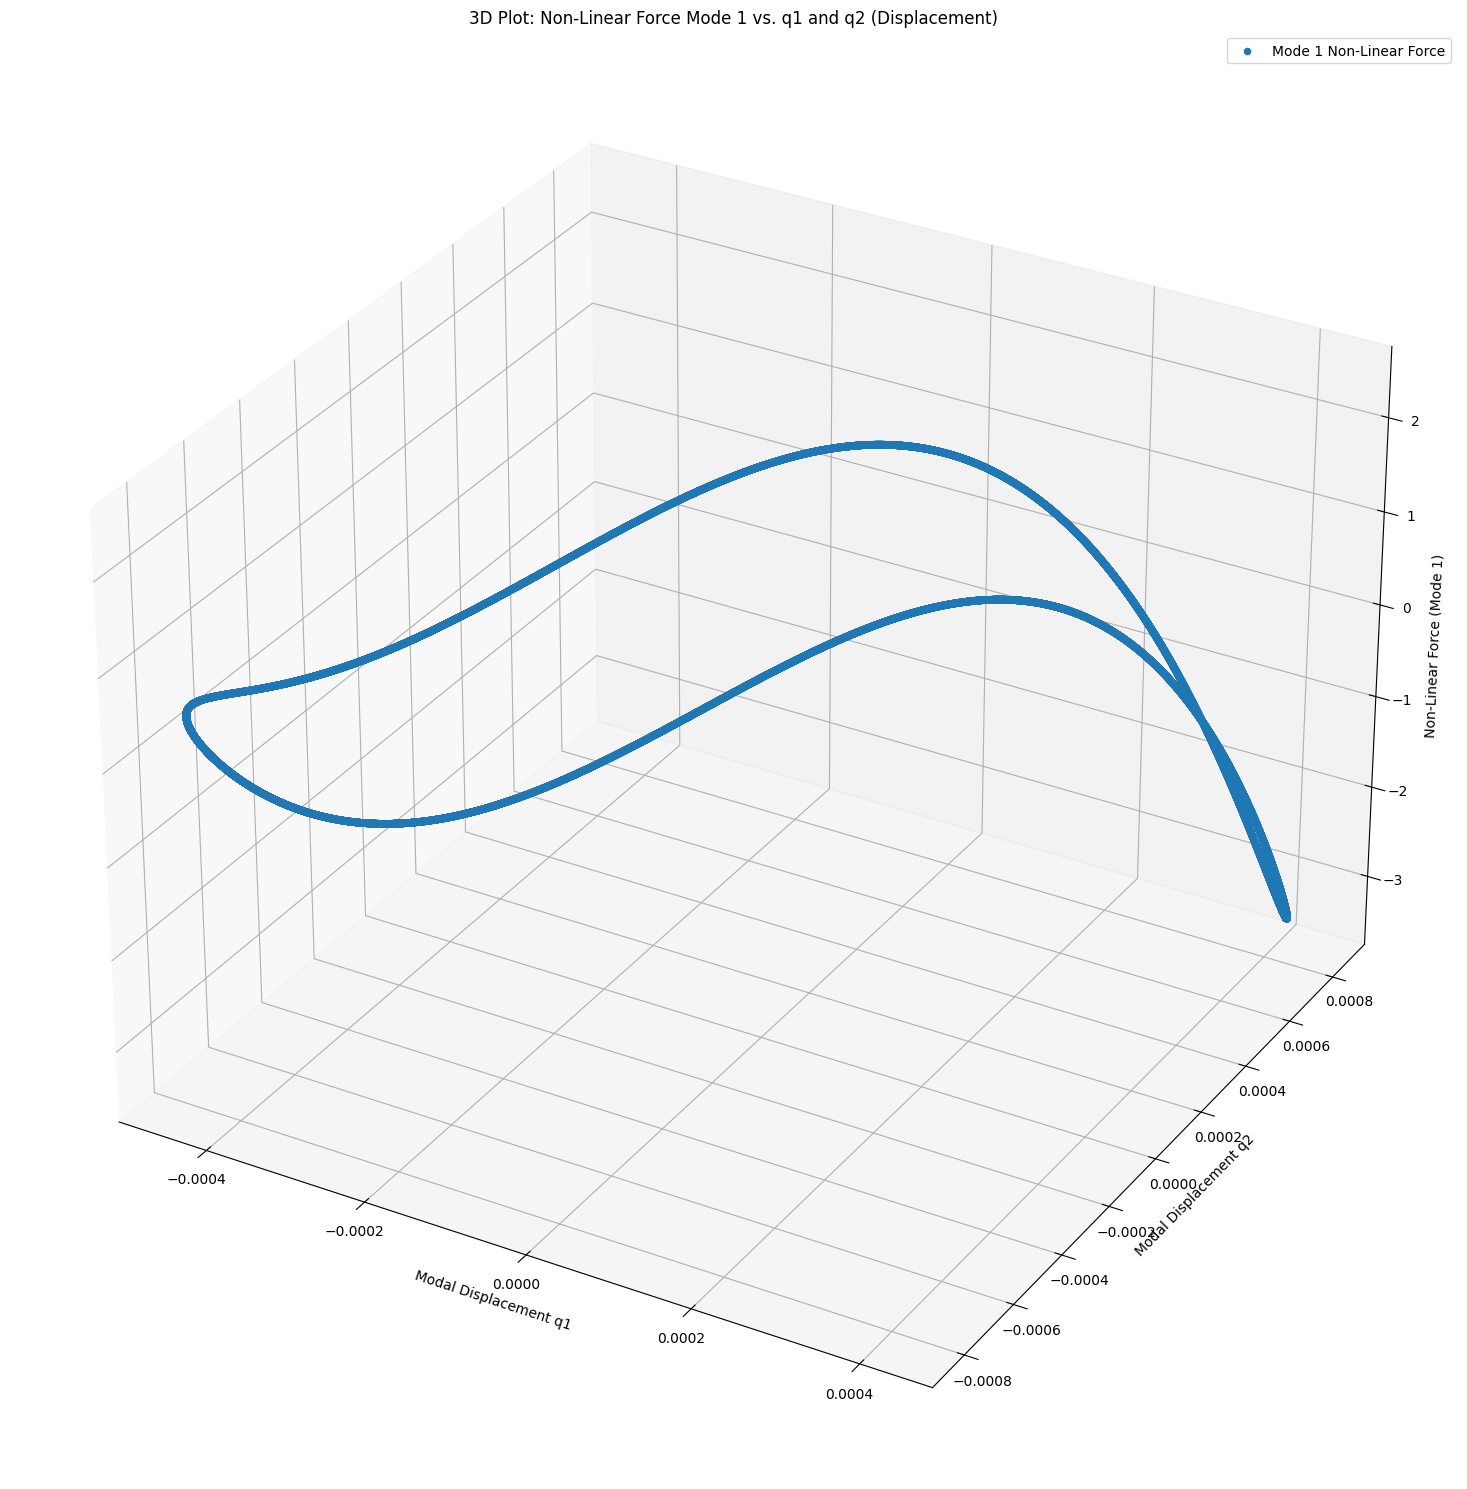

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Plot 1: Non-Linear Force Mode 1 vs. Modal Displacement q1 and q2 ---
fig1 = plt.figure(figsize=(15, 15)) # Increased figure size
ax1 = fig1.add_subplot(111, projection='3d')

ax1.scatter(modal_disp_q1_coords, modal_disp_q2_coords, Non_linear_force_mode1, cmap='viridis', label='Mode 1 Non-Linear Force')
ax1.set_xlabel('Modal Displacement q1')
ax1.set_ylabel('Modal Displacement q2')
ax1.set_zlabel('Non-Linear Force (Mode 1)')
ax1.set_title('3D Plot: Non-Linear Force Mode 1 vs. q1 and q2 (Displacement)')
plt.legend()
plt.tight_layout()
plt.show()

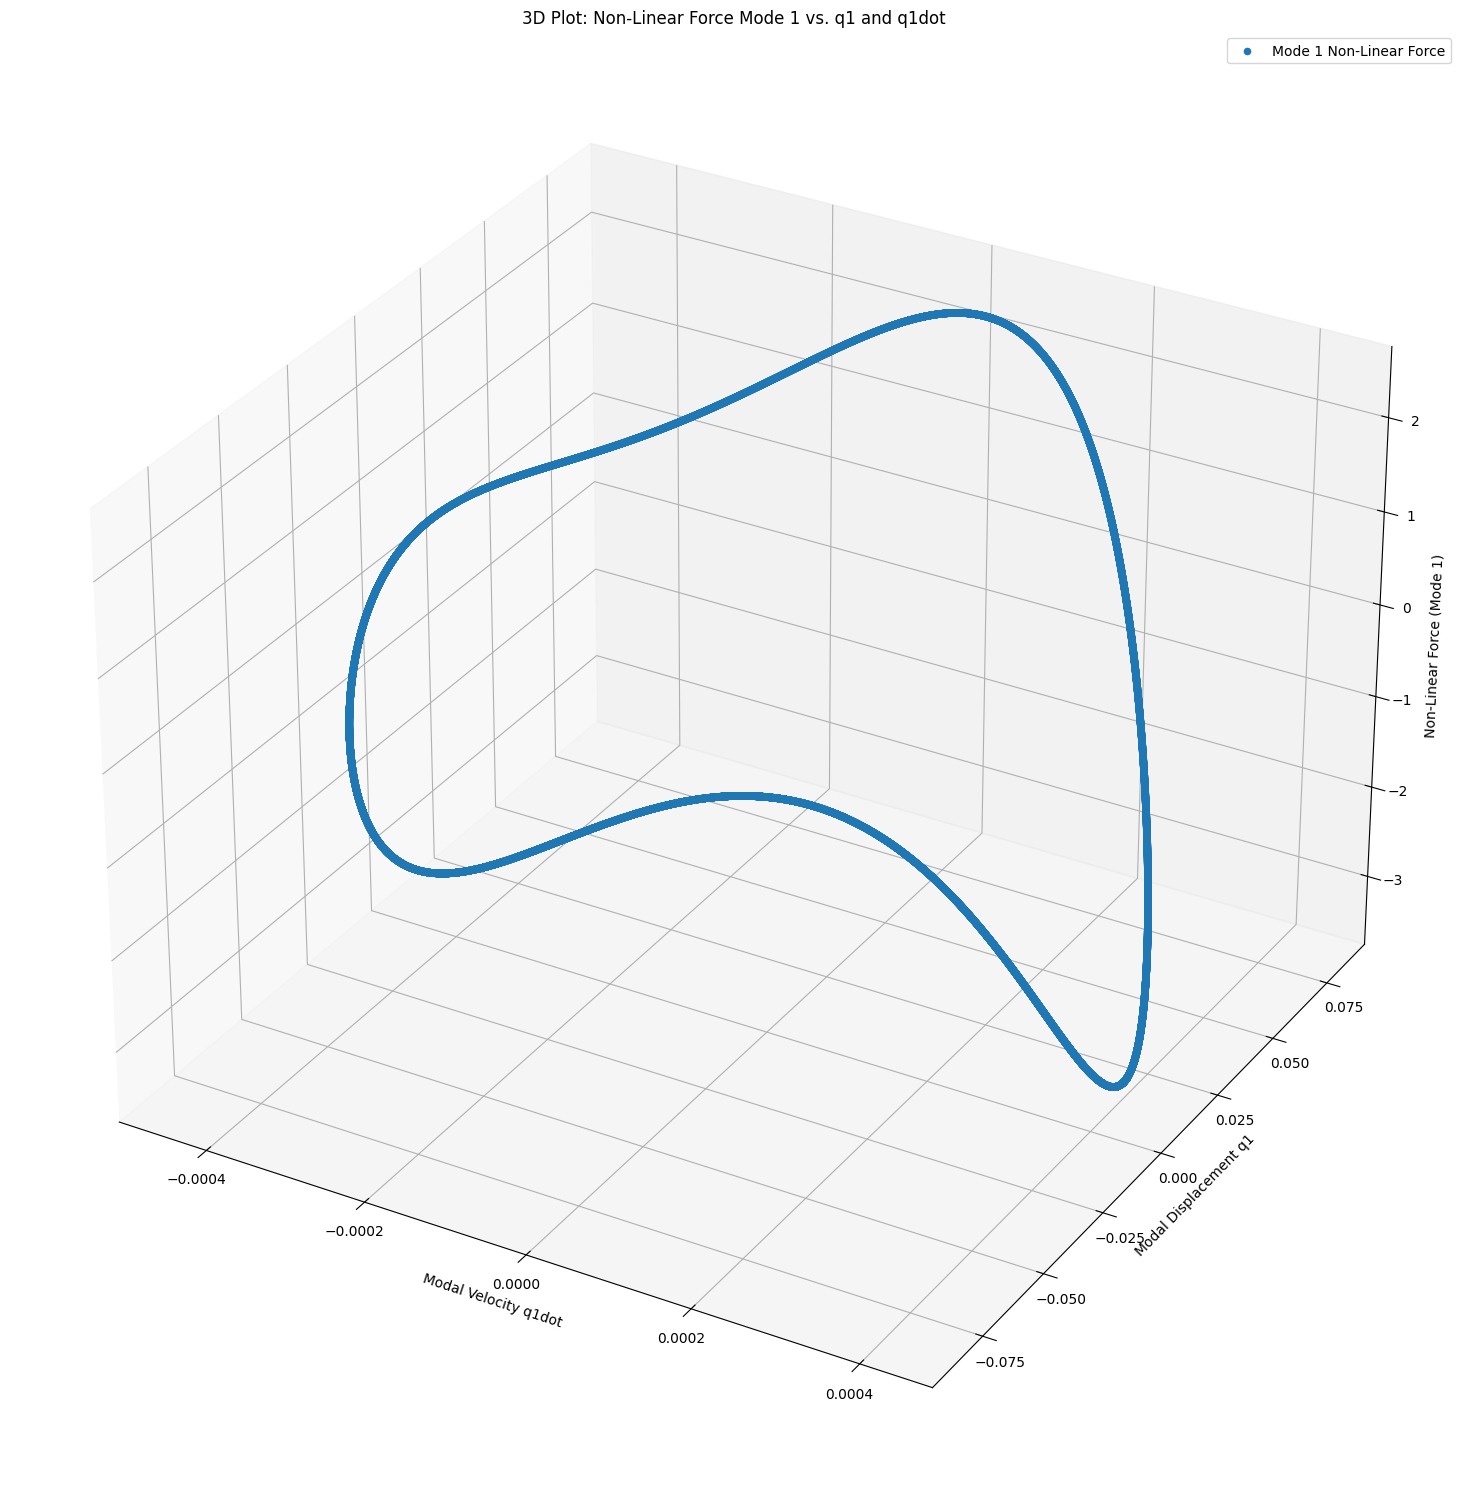

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

# Pass Non_linear_force_mode1 to the 'c' parameter for colormapping
ax.scatter(modal_disp_q1_coords, modal_vel_q1_coords, Non_linear_force_mode1,  label='Mode 1 Non-Linear Force')
ax.set_ylabel('Modal Displacement q1')
ax.set_xlabel('Modal Velocity q1dot')
ax.set_zlabel('Non-Linear Force (Mode 1)')
ax.set_title('3D Plot: Non-Linear Force Mode 1 vs. q1 and q1dot')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:

combined_df = pd.concat([
    Non_linear_force_02g_df.rename(columns={'Non_Linear_Force': 'Non_linear_Force'}),
    Modal_displacement_df.rename(columns={'Modal_displacement': 'Modal_Displacement'}),
    Modal_velocity_df.rename(columns={'Modal_velocity': 'Modal_Velocity'})
], axis=1)

In [23]:
combined_df.to_csv('Non_linear_force_4m_04g.csv', index=False)
print(f'Saved {len(combined_df)} rows → Non_linear_force_4m_04g.csv')

Saved 81922 rows → Non_linear_force_4m_04g.csv
